Retrieving SummaryDoc documents:   0%|          | 0/6087 [00:00<?, ?it/s]

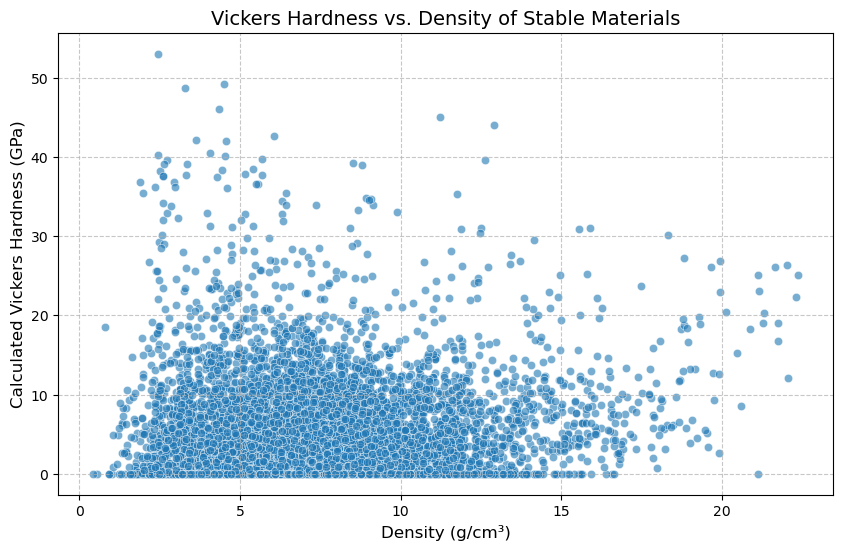

In [20]:
!pip install mp-api
apikey = "4Fxu8kCP9i4QlEKWL4gUCKY8WfTujzM8"
from mp_api.client import MPRester
import matplotlib.pyplot as plt
import pandas as pd

def get_hardness_and_density(step=1):
    
    results1 = []
    
    with MPRester(apikey) as mpr:
        try:
            docs = mpr.materials.summary.search(
                has_props=["elasticity"],
                is_stable=True,
                fields=["material_id", "formula_pretty", "bulk_modulus", "shear_modulus","density","formation_energy_per_atom","band_gap","volume",
                        "nsites","symmetry"]
            )
            
            sampled_docs = docs[::step]
            
            for doc in sampled_docs:
                b_val = None
                g_val = None
                
                if doc.bulk_modulus:
                    b_val = doc.bulk_modulus.get('vrh') if isinstance(doc.bulk_modulus, dict) else getattr(doc.bulk_modulus, 'vrh', None)
                
                if doc.shear_modulus:
                    g_val = doc.shear_modulus.get('vrh') if isinstance(doc.shear_modulus, dict) else getattr(doc.shear_modulus, 'vrh', None)

                if b_val is not None and g_val is not None and b_val > 0:
                    k = g_val / b_val
                    hv_gpa = 2 * (pow(k**2 * g_val, 0.585)) - 3

                    hv_final = max(0, hv_gpa)
                    
                    results1.append({
                        "id": str(doc.material_id),
                        "formula": doc.formula_pretty,
                        "density": doc.density,
                        "bulk_modulus": round(b_val, 2),
                        "shear_modulus": round(g_val, 2),
                        "pugh_ratio": round(k, 3),
                        "vickers_hardness_gpa": round(hv_final, 2)
                    })
                    
        except Exception:
            pass
            
    return results1

hardness_data = get_hardness_and_density(step=1)
df_raw = pd.DataFrame(hardness_data)
df_raw.to_csv("mp_hardness_data.csv", index=False)

dx = [item['density'] for item in hardness_data]
hy = [item['vickers_hardness_gpa'] for item in hardness_data]

plt.figure(figsize=(10, 6))
plt.scatter(dx, hy, alpha=0.6, edgecolors='w', linewidth=0.5)

plt.title(f"Vickers Hardness vs. Density of Stable Materials", fontsize=14)
plt.xlabel("Density (g/cm³)", fontsize=12)
plt.ylabel("Calculated Vickers Hardness (GPa)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)